# pyNISAR · quad polarization

Measured western Great Lakes example, 6 November 2025. Run all cells with LIVE=False to reproduce the bundled observations without NASA credentials. Set LIVE=True for the documented remote example. Source and package remain private; see README for installation.

In [1]:
# Install from the source checkout or an uploaded GitHub source ZIP.
from pathlib import Path
import importlib.util, subprocess, sys, zipfile
if importlib.util.find_spec("pynisar") is None:
    roots = [Path.cwd(), Path.cwd().parent, *Path.cwd().glob("pyNISAR*")]
    project = next((p for p in roots if (p / "pyproject.toml").is_file()), None)
    if project is None:
        from google.colab import files
        uploaded = files.upload()  # Select pyNISAR-main.zip downloaded from private GitHub.
        archive = next(Path(p) for p in uploaded if p.endswith(".zip"))
        destination = Path("pynisar_source").resolve()
        destination.mkdir(exist_ok=True)
        with zipfile.ZipFile(archive) as z:
            if any(not (destination / n).resolve().is_relative_to(destination) for n in z.namelist()):
                raise ValueError("Unsafe archive path.")
            z.extractall(destination)
        project = next(p.parent for p in destination.glob("*/pyproject.toml"))
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"{project.resolve()}[plot,discovery,notebook]"])

## Step 1 — Import libraries

In [2]:
from pathlib import Path
import earthaccess
import pynisar
from pynisar.discovery import collections, search
from IPython.display import display, HTML
import base64

## Step 2 — Define the study area

In [3]:
LIVE = False  # False: bundled measured data; True: NASA search and processing.
DOWNLOAD_H5 = False  # True downloads a whole HDF5; False reads a bounded remote window.
area = {"bbox": (-90.215, 46.435, -90.185, 46.465)}
# Or: area = {"aoi": "study_area.geojson"}
# Or: area = {"aoi": "study_area.gpkg", "layer": "boundary"}
dates = {"start": "2025-11-06", "end": "2025-11-07"}

## Step 3 — Sign in to Earthdata

In [4]:
if LIVE:
    auth = earthaccess.login(persist=False)
    if not auth.authenticated:
        raise RuntimeError("Sign in with your own NASA Earthdata account.")

## Step 4 — Search NISAR

In [5]:
if LIVE:
    choices = [c for c in collections() if "GCOV" in c["short_name"] and "PROVISIONAL" in c["short_name"]]
    if not choices:
        raise RuntimeError("No provisional GCOV collection found. Inspect collections().")
    scenes = search(choices[0]["concept_id"], **area, **dates, count=50)
    reference = Path(pynisar.sample("quad").info["source"]).stem
    scene = next((s for s in scenes if reference in s["umm"]["GranuleUR"]), None)
    if scene is None:
        candidates = [s for s in scenes if "_QP" in s["umm"]["GranuleUR"]]
        if not candidates:
            raise RuntimeError("No candidate quad acquisition found. Change the AOI/dates or inspect scenes for another polarization.")
        scene = candidates[0]
    print(scene["umm"]["GranuleUR"])

## Step 5 — Generate polarimetric products

In [6]:
settings = {"frequency": "A", "channels": ['HH', 'HV', 'VH', 'VV'], "looks": (1, 1)}
settings["reciprocal"] = True  # Explicit C3 / Pauli T3 reciprocity assumption.
if not LIVE:
    run = pynisar.process_sample("outputs/quad", mode="quad")
else:
    if "aoi" in area:
        from pynisar.aoi import read_aoi
        point = read_aoi(area["aoi"], layer=area.get("layer")).geometry.union_all().representative_point()
        center = (point.x, point.y)
    else:
        w, s, e, n = area["bbox"]
        center = ((w + e) / 2, (s + n) / 2)
    if DOWNLOAD_H5:
        files = earthaccess.download([scene], local_path="data/quad")
        source = next(Path(p) for p in files if Path(p).suffix.lower() == ".h5")
        run = pynisar.process(source, "outputs/quad", **settings, center=center, window_size=128)
    else:
        url = next(u for u in scene.data_links() if u.split("?")[0].endswith(".h5"))
        with pynisar.open_remote(url, max_mb=256) as source:
            run = pynisar.process(source, "outputs/quad", **settings, center=center, window_size=128)

## Step 6 — Plot the results


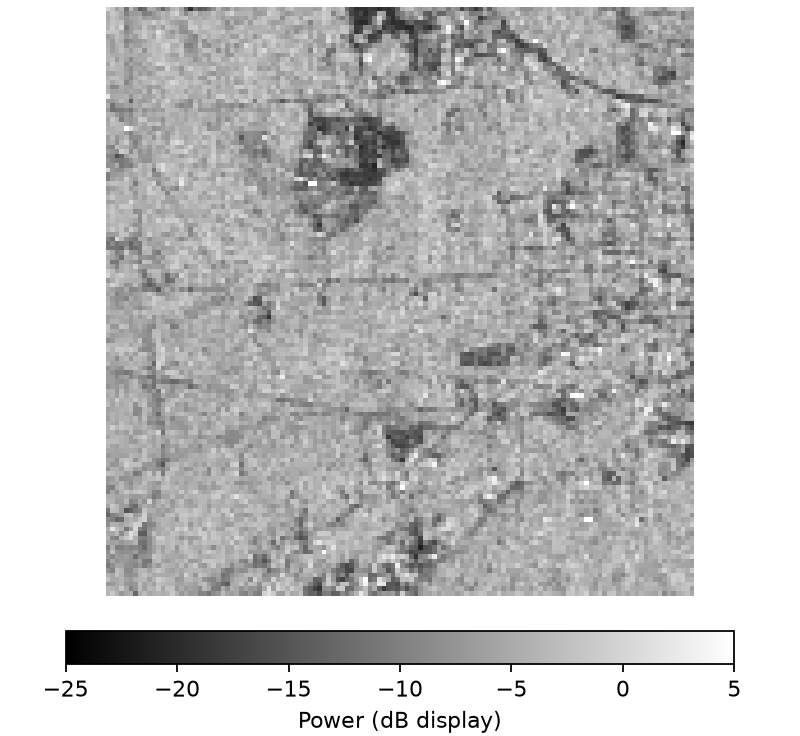
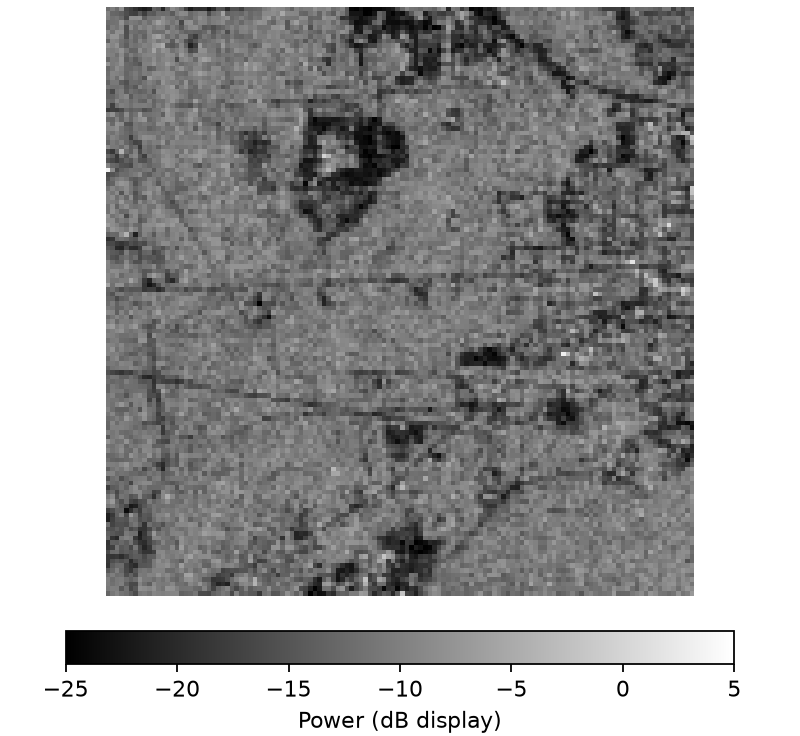
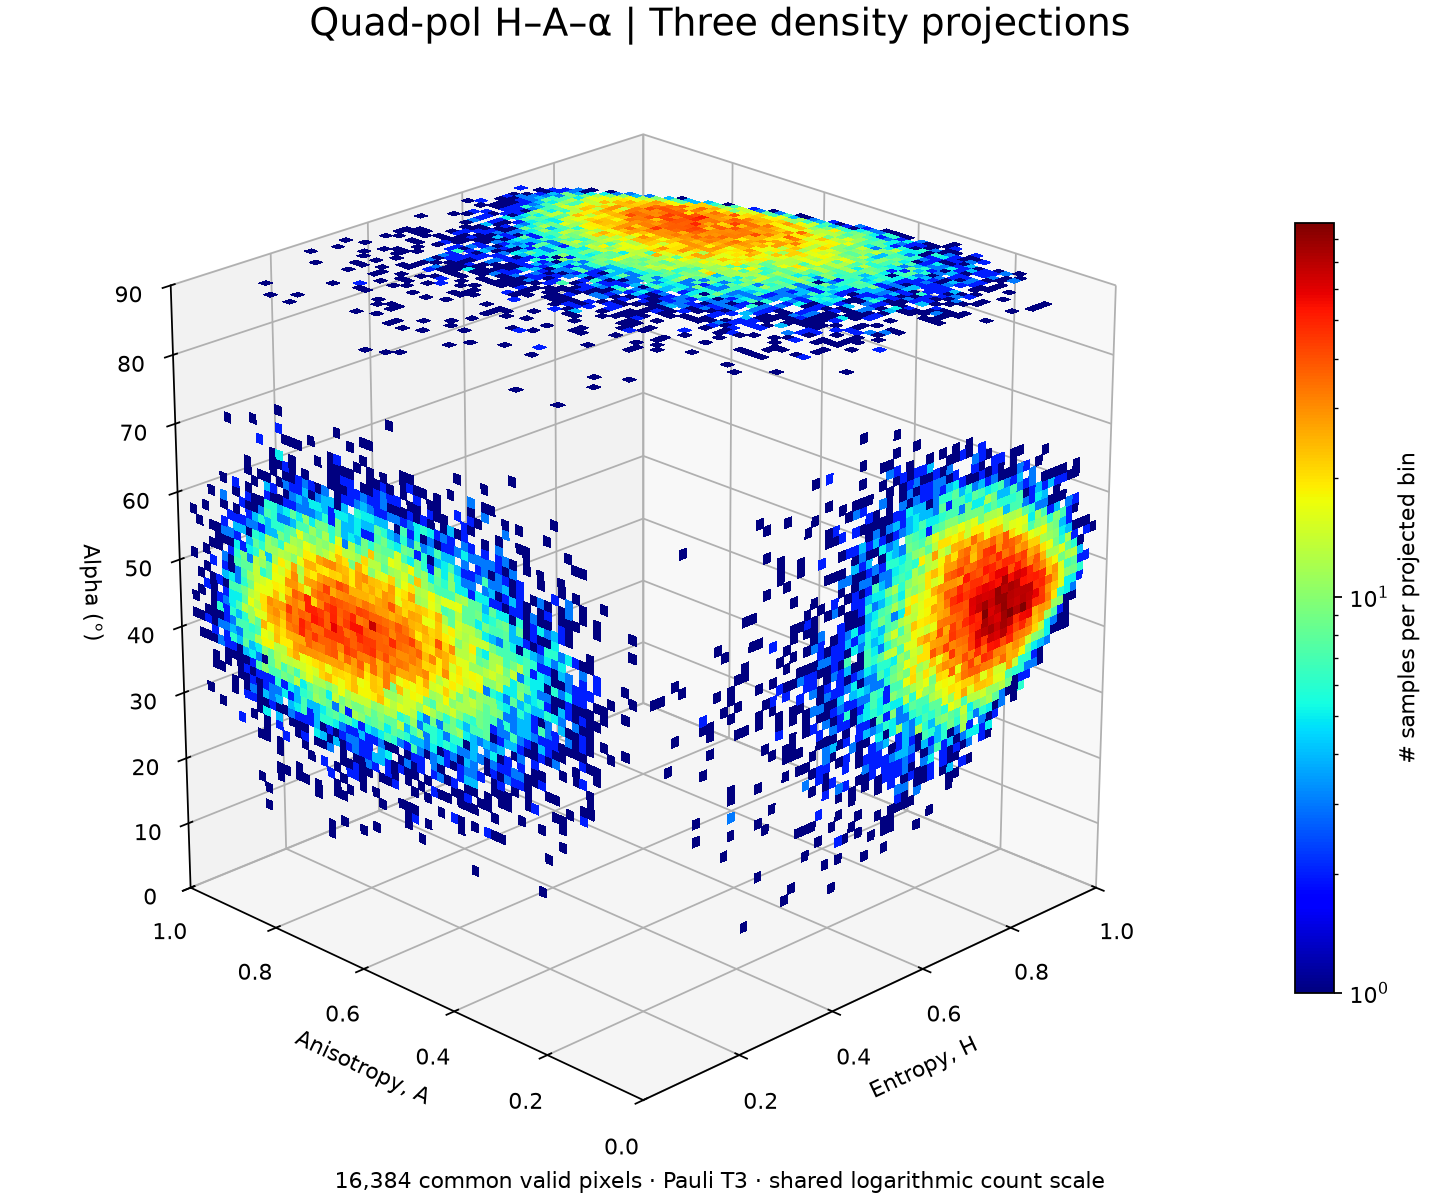

In [7]:
figures = pynisar.plot_gallery(run)
images = "".join('<img style="width:32%;vertical-align:top" src="data:image/png;base64,'
                 + base64.b64encode(p.read_bytes()).decode() + '">' for p in figures)
display(HTML(images))

## Your AOI and large products
The bundled mode uses its saved footprint and looks; it does not process the AOI entered above. In LIVE mode, the example selects a pinned, known quad acquisition; for another area/date inspect `scenes`, choose `scene = scenes[index]`, and confirm channels/covariance before processing. Preview windows are centered on the AOI, not polygon-masked. Use `process_tile(source, "products", **settings, **area, scope="aoi", chunk_size=256)` for masked products from a downloaded HDF5, or `scope="tile"` for the full tile. `process_batch` adds optional workers and success-only source deletion. Keep your HDF5 until previews are complete. No credentials are stored in notebook outputs.